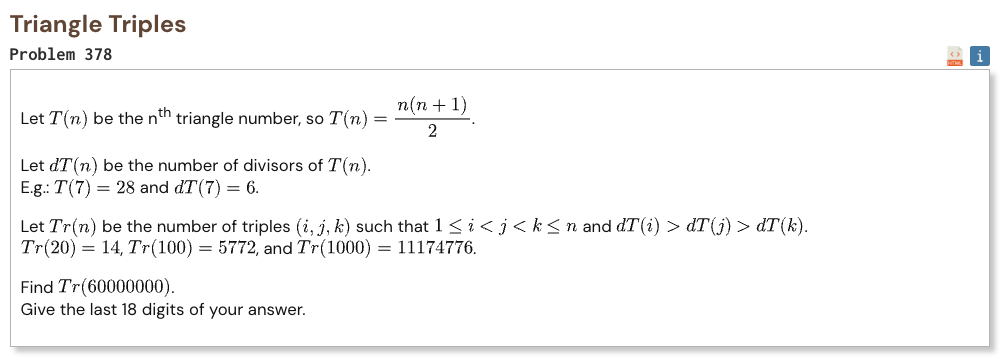

## Initial approach

* use a linear sieve to calculate divisor counts for every number up to the limit
* split each triangle number into two coprime parts before multiplying their divisor counts
* process the divisor counts from left to right
* keep one Fenwick tree for single earlier values and another for decreasing pairs
* for each new value count earlier pairs whose final value is strictly larger
* add these pairs to the triple total and keep only the last 18 digits
* use numpy for compact numeric arrays and numba to make the large loops fast

In [1]:
import numpy as np
from numba import njit

MOD = 10**18


@njit
def build_divisor_counts(limit):
    spf = np.zeros(limit + 1, dtype=np.int32)
    divisor_count = np.ones(limit + 1, dtype=np.uint16)
    exponent = np.zeros(limit + 1, dtype=np.uint8)
    primes = np.empty(limit // 8 + 100, dtype=np.int32)

    prime_count = 0
    divisor_count[0] = 0

    for value in range(2, limit + 1):
        if spf[value] == 0:
            spf[value] = value
            exponent[value] = 1
            divisor_count[value] = 2
            primes[prime_count] = value
            prime_count += 1

        for index in range(prime_count):
            prime = primes[index]
            product = value * prime

            if product > limit:
                break

            spf[product] = prime

            if prime == spf[value]:
                new_exponent = exponent[value] + 1
                exponent[product] = new_exponent
                divisor_count[product] = (
                    divisor_count[value]
                    // (exponent[value] + 1)
                    * (new_exponent + 1)
                )
                break

            exponent[product] = 1
            divisor_count[product] = divisor_count[value] * 2

    return divisor_count


@njit
def triangle_divisor_count(index, divisor_count):
    if index % 2 == 0:
        return np.int64(divisor_count[index // 2]) * np.int64(
            divisor_count[index + 1]
        )

    return np.int64(divisor_count[index]) * np.int64(
        divisor_count[(index + 1) // 2]
    )


@njit
def fenwick_add(tree, index, value):
    index = np.int64(index)
    size = np.int64(len(tree))

    while index < size:
        tree[index] += value
        index += index & -index


@njit
def fenwick_sum(tree, index):
    index = np.int64(index)
    total = np.int64(0)

    while index > 0:
        total += tree[index]
        index -= index & -index

    return total


@njit
def count_triangle_triples(limit, divisor_count):
    maximum_value = np.int64(0)

    for index in range(1, limit + 1):
        value = triangle_divisor_count(index, divisor_count)

        if value > maximum_value:
            maximum_value = value

    tree_size = int(maximum_value) + 2

    singles_tree = np.zeros(tree_size, dtype=np.int64)
    pairs_tree = np.zeros(tree_size, dtype=np.int64)

    singles_total = np.int64(0)
    pairs_total = np.int64(0)
    triples_total = np.int64(0)

    for index in range(1, limit + 1):
        value = triangle_divisor_count(index, divisor_count)

        pairs_not_greater = fenwick_sum(pairs_tree, value)
        greater_pairs = pairs_total - pairs_not_greater

        triples_total = (triples_total + greater_pairs) % MOD

        singles_not_greater = fenwick_sum(singles_tree, value)
        greater_singles = singles_total - singles_not_greater

        fenwick_add(pairs_tree, value, greater_singles)
        fenwick_add(singles_tree, value, 1)

        pairs_total += greater_singles
        singles_total += 1

    return triples_total


def solve(limit):
    divisor_count = build_divisor_counts(limit + 1)
    return count_triangle_triples(limit, divisor_count)


assert solve(20) == 14
assert solve(100) == 5772
assert solve(1000) == 11174776

In [2]:
%%time
result = solve(60_000_000)
print("Result:", f"{result:018d}")

Result: 147534623725724718
CPU times: user 1.97 s, sys: 33.7 ms, total: 2.01 s
Wall time: 2.01 s
